# Module 04 — EDA and Export Summary

This module creates concise visuals and writes final analysis-friendly exports.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
processed_dir = Path('/Users/game./Documents/Sandbox/Bond_starter_project_public/data/processed')
cleaned_path = processed_dir / 'sec_bond_cleaned.csv'
if not cleaned_path.exists():
    raise FileNotFoundError('Run module 02 first to create sec_bond_cleaned.csv')

df = pd.read_csv(cleaned_path, low_memory=False)
date_col = 'maturity__issue_date' if 'maturity__issue_date' in df.columns else None
rate_col = 'coupon__rate' if 'coupon__rate' in df.columns else None

if date_col is not None:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
if rate_col is not None:
    df[rate_col] = pd.to_numeric(df[rate_col], errors='coerce')

print(f'Loaded cleaned rows: {len(df):,}')

Loaded cleaned rows: 214,205


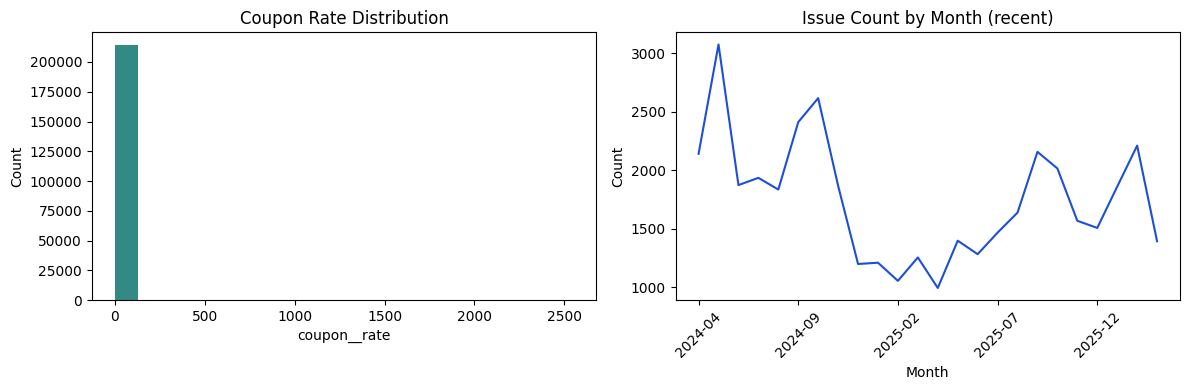

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if rate_col is not None and df[rate_col].notna().any():
    axes[0].hist(df[rate_col].dropna(), bins=20, color='#0f766e', alpha=0.85)
    axes[0].set_title('Coupon Rate Distribution')
    axes[0].set_xlabel(rate_col)
    axes[0].set_ylabel('Count')
else:
    axes[0].text(0.5, 0.5, 'No coupon column', ha='center', va='center')
    axes[0].set_axis_off()

if date_col is not None and df[date_col].notna().any():
    monthly = df.assign(month=df[date_col].dt.to_period('M').astype(str)).groupby('month').size()
    monthly.tail(24).plot(ax=axes[1], color='#1d4ed8')
    axes[1].set_title('Issue Count by Month (recent)')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].text(0.5, 0.5, 'No date column', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

In [4]:
summary_path = processed_dir / 'sec_bond_summary_stats.csv'
summary = pd.DataFrame({
    'metric': ['rows', 'columns', 'min_coupon', 'max_coupon', 'avg_coupon'],
    'value': [
        len(df),
        df.shape[1],
        float(df[rate_col].min()) if rate_col is not None and df[rate_col].notna().any() else None,
        float(df[rate_col].max()) if rate_col is not None and df[rate_col].notna().any() else None,
        float(df[rate_col].mean()) if rate_col is not None and df[rate_col].notna().any() else None,
    ]
})

summary.to_csv(summary_path, index=False)
print(f'Saved summary stats: {summary_path}')
display(summary)

Saved summary stats: /Users/game./Documents/Sandbox/Bond_starter_project_public/data/processed/sec_bond_summary_stats.csv


,metric,value
0,rows,214205.000000
1,columns,26.000000
2,min_coupon,0.000000
3,max_coupon,2550.000000
4,avg_coupon,4.829054
